# Phys 501 Final Project - Practical Implementation of Fourier-Bessel Series

# Andrew Koren



Since the preliminaries section is primarily content we've already covered in class, I've skipped through some of the derivations we've already worked through. They provide important background before we discuss the continuous Hankel transform, so I couldn't remove the section entirely.

---
 Preliminaries
---

In class, Bessel Functions have primarily appeared as solutions to differential equations in polar or cylindrical coordinates. In cylindrical coordinates, the Laplace equation $\nabla^2 u = 0 $ and simliar problems (heat equation, wave equation, etc.) often produce the Bessel Differential Equation

$$
r^2 R''(r) + r R'(r) + (k^2r^2 - n^2)R(r) = 0
$$

where $n$ groups together the separate solutions not dependent on $r$. This is solved by the Bessel functions $J_n(k r)$ and $Y_n(k r)$, with weight and order $n$ depending on the boundary conditions used. 

One key feature of Bessel functions is their orthogonality, which allows for a variety of boundaries and initial conditions to be represented. According to Sturm-Lioville theory, putting the Bessel Differential Equation in Self-adjoint form will allow us to define a scalar product with eigenfunctions as solutions to the ODE. If this is the case, each eigenfunction which corresponds to a different eigenvalue will be orthogonal according to the scalar product, allowing us to expand various functions within the domain of the solution in terms of Bessel Functions. 

In class, we derived the self-adjoint form by dividing the ODE by $r$ and found the weight function $w(r) = r$ as

$$
\\  r R''(r) + R'(r) + \left(k^2 r - {n^2 \over r}\right) R(r) = 0
\\  (p(r)R'(r))' + \left(\lambda w(r) - q(r)\right) R(r) = 0
\\  p(r) = r
\qquad
    \lambda = k^2
\qquad
    w(r) = r
\qquad q(r) = {n^2 \over r},
$$

yielding the scalar product as

$$
\langle f, g \rangle = \int_{a}^{b} f^*(r) g(r) r dr.
$$

Interestingly, while any bessel function $J_n(kr)$ is an eigenfunction of $\mathcal L_n(r) = {d \over dr}\left(r {d \over dr} \right) + \left(\lambda r - {n^2 \over r} \right)$, the scalar product yields an orthogonality condition on the domain $(0,1]$ specifically when $k$ is a zero of the eigenfunction $J_n(x_{n,k})=0$:

$$ 
      \langle J_{n}(x_{n,k}x), J_{n}(x_{n,k'}x) \rangle
    = \int_0^1 J_{n}(x_{n,k}x) J_{n}(x_{n,k'}) x dx 
    = {\delta_{kk'} \over 2} J^2_{n+1}(x_{n,k}).
$$
Or, rescaled to the domain $(0, r_{\text{max}}]$ with $x \rightarrow r/r_{\text{max}}$:
$$
    \alpha_{n,k} = {x_{n,k} \over r_{\text{max}}}    
\\  J_n(\alpha_{n,k}r_{\text{max}}) = 0
\\  \langle J_{n}(\alpha_{n,k}r), J_{n}(\alpha_{n,k'}r) \rangle  
    = {\delta_{kk'} r_{\text{max}}^2 \over 2} J^2_{n+1}(\alpha_{n,k}).
$$

As we've seen in class, it is this orthogonality which allows us to expand any "good" function in the Hilbert space of this scalar product, and we used this to solve various differential equations. However, this project is less focused on solving differential equations and is more interested in understanding these expansions. We will be going in-depth on what kinds of signals/distributions can be accurately recreated by Bessel functions, as well as look at a _continuous_ expansion in the form of the Hankel Transform.


<!-- Interestingly, the Bessel functions are eigenfunctions on the domain $[0,1]$ only when $k$ corresponds to a zero of a Bessel function $k = x_{n,k}$, with eigenvalue $\lambda = k^2 = x_{n,k}^2$

$$
    J_n(x_{n,k}) = 0
\\  \mathcal L_n(r) = {d \over dr}\left(r {d \over dr} \right) + \left(\lambda r - {n^2 \over r} \right)
\\  \mathcal L_n(x) J_n(x_{n,k} x) = x_{n,k}^2 J_n(x_{n,k} x)
$$ -->

---
 Fourier-Bessel expansion and Hankel Transform
---

Including the orthogonality of the Fourier expansion, any function $f(r,\theta)$ can be expanded into the Fourier-Bessel series as

$$
    f(r,\theta) = \sum_{m=-\infty}^\infty \sum_{k=1}^\infty c_{m,k} J_n(\alpha_{n,k}r)e^{im\theta}
\\  c_{m,k} 
    = \left\langle
      \frac{\left\langle f(r,\theta), e^{im\theta} \right\rangle}
           {\left\| e^{im\theta} \right\|^2},
      J_n(\alpha_{n,k}r)
      \right\rangle \Big/ \left\| J_n(\alpha_{n,k} r) \right\|^2 

\\  = {1 \over \pi r_{\text{max}^2 J_{n+1}^2 (\alpha_{n,k})}} \int_0^{r_{\text{max}}} \int_0^{2\pi} f(r,\theta) e^{-im \theta} J_n(\alpha_{n,k r})r d\theta dr
$$

Note however, that this isn't the textbook definition of the expansion. Can you see what's off? Our textbook expansion defines the order of the bessel function as $n=|m|$, but this isn't strictly necessary for convergence. In the book, the choice $n=|m|$ is obvious since the seperable solution $\psi = R(r)\Theta(\theta)$ to the Laplace equation or other PDEs forces the Bessel differential equation to have $n$ be the same as an angular mode number. Sturm-Lioville theory doesn't directly force $n=|m|$. 

We can show an example of this by reconstructing a simple function, like $f(r,\theta) = r(1-r) \cos \theta$, and a simple visual inspection should show this works. I've moved the majority of the code to a separate module `finalproj.py` for clarity

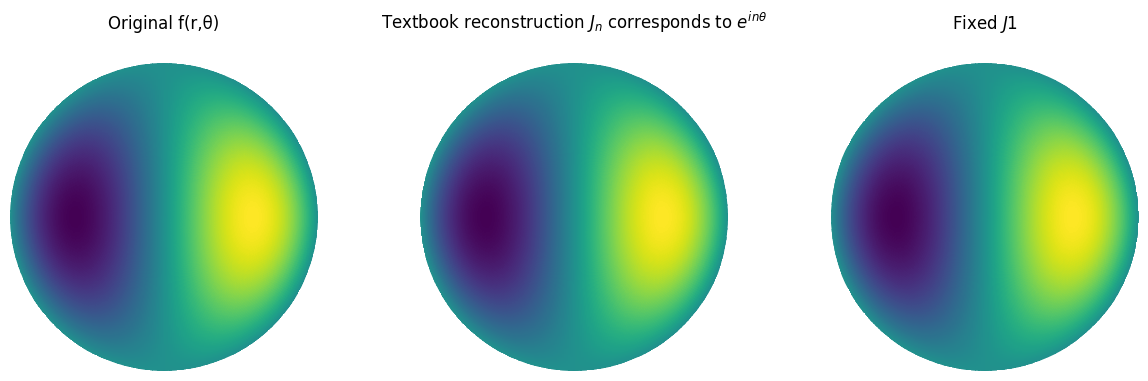

In [1]:
import numpy as np
from finalproj import naive_f_expansion, recon_f_from_naive, plot_3_spheres
import matplotlib.pyplot as plt

def f(r, theta, R):
    return r*(1-r*r)*np.cos(theta)

# parameters
R = 1.0
Nr, Ntheta = 400, 400
N, M = 10, 10 # angular, radial modes
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)
fixed_order = 1

plot_3_spheres(f, R, Nr, Ntheta, N, M, fixed_order)

According to my preferred method of quantifying error, the eyeball method, it looks like using a fixed order $n=1$ has a bit of trouble recreating the function, while the textbook method has no issues. Surely higher order bessel functions won't struggle more. Let's try $J_{19}(r/r_{\text{max}})$

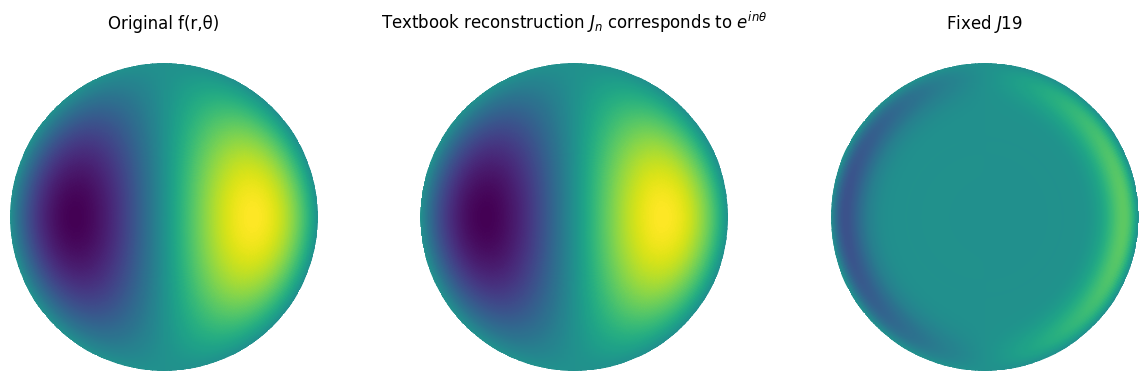

In [2]:
# parameters
R = 1.0
Nr, Ntheta = 400, 400
N, M = 10, 10 # angular, radial modes
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)
fixed_order = 19

plot_3_spheres(f, R, Nr, Ntheta, N, M, fixed_order)

That looks a bit further off. In reality, Bessel function order in the Bessel-Fourier series goes deeper than solutions to differential equations. I've had trouble finding a textbook which doesn't argue that this comes from an eigenvalue problem, but the well-developed discussion around Fourier series and Fourier transforms does give us some insight.

The visual discrepancy comes down to the behavior of Bessel functions near the origin. For small arguments $x$, the Bessel function scales as:

$$ J_n(x) \sim \frac{1}{\Gamma(n+1)}\left(\frac{x}{2}\right)^n $$

In our test function $f(r,\theta) = r(1-r^2)\cos\theta$, the radial dependence near the origin is linear ($\sim r^1$). When we fixed the expansion order to $n=19$, we attempted to approximate a function that behaves like $r$ using a basis set that behaves like $r^{19}$. While the set of Bessel functions $\{J_{19}(\alpha_{19,k} r)\}_k$ is technically complete in $L^2$, the spectral convergence is indistinguishably slow for functions that do not respect the boundary conditions at the origin implied by the order $n$. To fit a linear slope with a sum of extremely flat functions requires massive coefficients and precise cancellation, which fails numerically.

While this explains what we observe above, I still had trouble understanding why the exact choice $n=|m|$ has the best convergence. Rather than looking at the discrete case, we can consider the 2D Fourier Transform of $f(r, \theta) = g(r)e^{im\theta}$, a function with garunteed radial and angular components. 
This section closely follows Fourier Analysis in Polar and Sperical Coordinates (see further reading). In polar coordinates, the 2D Fourier transform is

$$
F(k) = \iint_{\mathbb{R}^2} f(\mathbf{r}) e^{-i \mathbf{k} \cdot \mathbf{r}} \, dA
    = \int_0^\infty \int_0^{2\pi} f(r, \theta) e^{-i kr \cos(\theta - \phi)} \, r \, d\theta \, dr,
$$
so the transform of $f(r,\theta)$ is
$$
\begin{aligned}
F(k, \phi) &= \int_0^\infty \int_0^{2\pi} f(r, \theta) e^{-i \mathbf{k} \cdot \mathbf{r}} \, r \, d\theta \, dr \\
&= \int_0^\infty g(r) r \left[ \int_0^{2\pi} e^{im\theta} e^{-ikr \cos(\theta - \phi)} d\theta \right] dr
\end{aligned}.
$$
Using the Jacobi-Anger expansion identity:
$$ \int_0^{2\pi} e^{im\theta} e^{-ikr \cos(\theta - \phi)} d\theta = 2\pi (-i)^m e^{im\phi} J_m(kr) $$

We arrive at:
$$ F(k, \phi) = 2\pi (-i)^m e^{im\phi} \int_0^\infty g(r) J_m(kr) r \, dr $$

This integral is exactly the **Hankel Transform of order $m$**. This reveals that the Fourier-Bessel series is not just an arbitrary choice of orthogonal basis functions, but closely matches a special case of the 2D Fourier Transform. This reveals the connection between angular frequency $m$ and order $n$ of the Bessel function, as we must have $n=|m|$ to transform the radial component. 

Therefore, we _can_ force an expansion using an arbitrary order $n$ via Sturm-Liouville orthogonality, doing so breaks the link to the Fourier Transform, which has built-in handling of $r=0$ singularities (it is valid across coordinate systems). The comparison between $J_n(x)$ for small $x$ and the well-known convergence of Fourier Transforms als explains why convergence is ruined for any function where $f(r) \not\sim r^n$.

---
 Quasispectral Discrete Hankel Transform
---

In truth, this whole demonstration with the colored spheres is cleverly selected. Functions which have details that aren't easily covered by lower modes can have difficulty converging. For example, the very basic expansion of $f(r,\theta)=1-x$ has large contributions from very large modes, and even using five times as many as in the previous example does not completely converge to the original function.

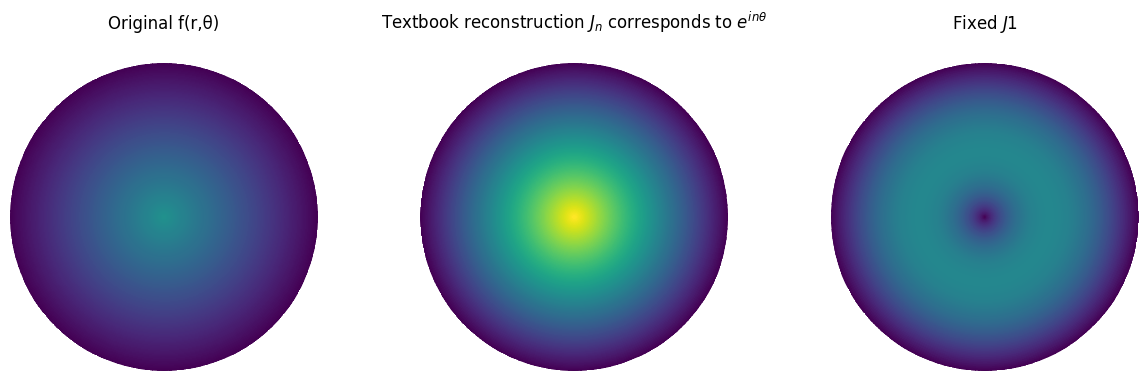

In [3]:
def f(r, theta, R):
    return 1-r

# parameters
R = 1.0
Nr, Ntheta = 400, 400
N, M = 50, 50 # angular, radial modes
r = np.linspace(0, R, Nr)
theta = np.linspace(0, 2*np.pi, Ntheta)
fixed_order = 1

plot_3_spheres(f, R, Nr, Ntheta, N, M, fixed_order)

While the function $f(r) = r(1-r^2)$ converged beautifully, the expansion for $f(r) = 1-r$ struggles significantly, particularly near the origin.

The reason for this failure lies in the geometry implied by polar coordinates. While a cone looks simple, at the tip ($r=0$) it is continuous but not differentiable.

Spectral methods, including Fourier-Bessel expansions, require smoothness to converge. Fourier transforms converge exponentially only when the target function is infinitely differentiable ($C^\infty$). The sum of smooth Bessel functions (which are flat or quadratically smooth at the origin) has trouble approximating the sharp, non-differentiable tip of a cone. This leads to the Gibbs phenomenon, where massive amounts of terms slowly eat away at the sharp feature. This limitation suggests that while standard expansions work for smooth physical fields (like drum modes), we need robust numerical methods to handle general cases.

Typically Fast Fourier Transforms (FFTs) are able to handle these using precise numerical methods that I'm not an expert in, so I decided to implement the Hankel Function equivalent, as described in **Zhou and Grisouard (2023)**. To understand how an implentation works, let's look again at the Hankel transform

$$ \tilde{f}(k) = \int_0^\infty f(r) J_n(kr) r \, dr $$

Notice the bounds are zero to infinity. The standard continuous Hankel transform assumes the function exists on an unbound domain. However, our project exists on a disk, $r \in [0, R]$ (which we rescale $r \rightarrow r/R$ to fit on a unit disk $r \in [0,1]$).

A naive implementation fails because it ignores the boundary conditions. In a finite domain, the spectrum is not continuous ($k$ can be anything); it is discrete ($k$ must be a root of the Bessel function to satisfy $J_n(k)=0$ at the wall). Therefore, we aren't actually looking for a continuous Hankel Transform and have to use a "Pseudospectral Discrete Hankel Transform (DHT)". 
A pseudospectral method assumes the function is a sum of global basis functions (Bessel functions), and the word "Pseudospectral" specifically refers to the technique of using a specific set of grid points (collocation points) in physical space that map exactly to the spectral coefficients, rather than linearlly spaced points. This garuntees discrete orthogonality, allowing for accurate transformation between real and $k$ space.

The method I chose from **Zhou and Grisouard (2023)** has two nice items:
1.  **The Grid:** It defines the physical grid points $r_{n,i}$ based on the roots of the Bessel function $J_n$ as $r_{n,i} = \alpha_{n,i} / \alpha_{n, N+1}$. This naturally clusters points where the basis functions oscillate most and ensures the boundary condition at $r=1$ is enforced.
2.  **Discrete Orthogonality:** They derive exact quadrature weights $w_{n,i}$ such that the transformation matrix is unitary. This means the transform satisfies a discrete form of Parseval's theorem (energy conservation), and more importantly, the forward and backward transforms are perfectly symmetric and stable matrix multiplications (symplectic).

These two features allow us to recreate arbitrarily complex functions so long as resolution is high enough. Due to sampling at the Nyquist frequency, we loose about half of resolution through this process. The final product of this project is this implementation, including the tools needed to perform transformation of images into Hankel/$k$-space, which you are free to play around with.

Further work could quantify error, make animations, spectrum editing, and simulate dynamics, but I think this project is alright where it is at.

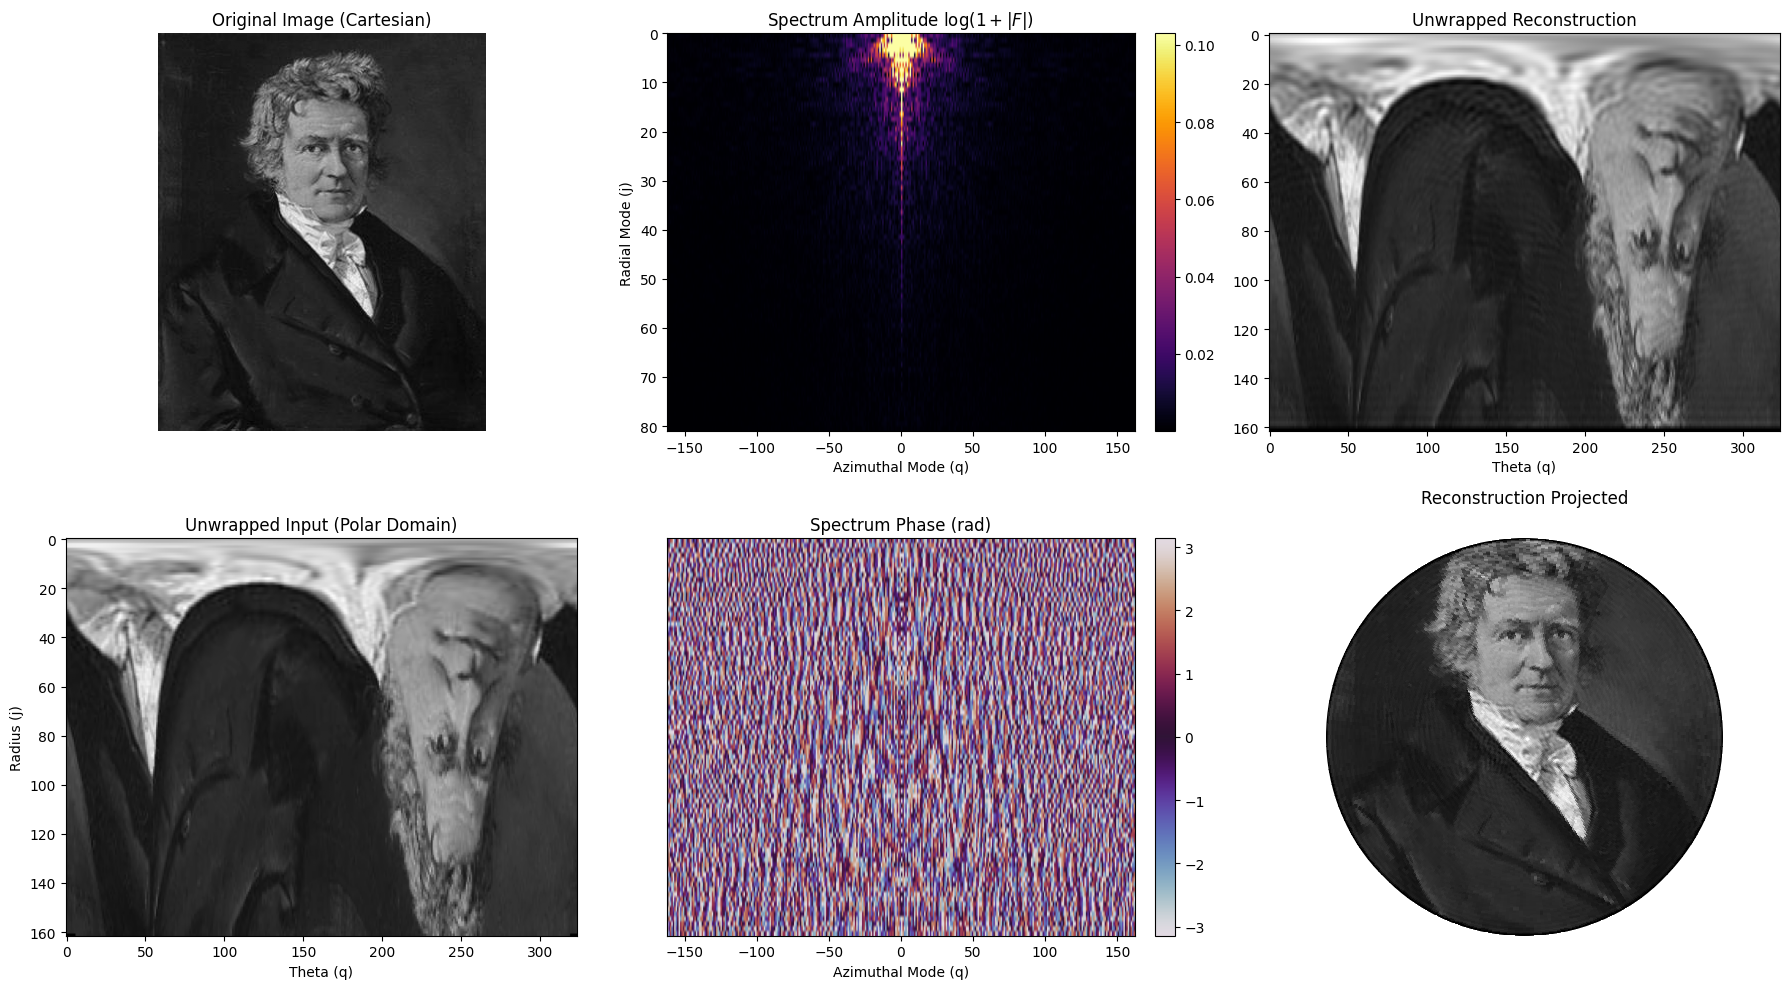

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from finalproj import Double_Transform, image_visualization

img = Image.open('Friedrich_Wilhelm_Bessel_(1839_painting).jpg').convert('L')
img_arr = np.asarray(img).astype(float) / 255.0  # Normalize 0-1

# Nr = Image Width / 4 since nyquist is 2*radial resolution
img_dim = min(img_arr.shape)
Nr = int(img_dim // 4)  
Nth = int(Nr * 4) # Nth should at least be Nr *2 according to paper
FFT_DHT = Double_Transform(Nr=Nr, Nth=Nth)

image_visualization(FFT_DHT, img_arr)

In [ ]:
from finalproj import sample_image_on_polar_grid
from PIL import Image

# perform transform of polar plot
polar_image = sample_image_on_polar_grid(img_arr, FFT_DHT)
coeffs = FFT_DHT.phys_to_spec(polar_image) # this is the transformed image
coeffs_shifted = np.fft.fftshift(coeffs, axes=0)

# renormalize for easy editing
spec_angle = ((np.angle(coeffs_shifted) + np.pi)/(2*np.pi)) # same as what is plotted
spec_mag = np.log1p(np.abs(coeffs_shifted))                 # same as what is plotted
spec_mag_max = spec_mag.max()

# convert to images
phase16 = (spec_angle * 65535).astype(np.uint16)
Image.fromarray(phase16).save("refphase.png")

mag16 = (spec_mag/spec_mag_max * 65535).astype(np.uint16)
Image.fromarray(mag16).save("refmag.png")

# --- Now open ms paint and add a layer on top to edit --- #

In [6]:
# --- use reference images to make a mask --- #

mask = np.asarray(Image.open('mask.png').convert('L')) / 255

spec_angle_post = spec_angle # left alone here
spec_mag_post = spec_mag * mask

# rebuild coeffs
# plots and coeffs are different
z = np.expm1(spec_mag_post)
theta = spec_angle_post*(2*np.pi) - np.pi

coeffs_shifted_post = z * np.exp(1j*theta)
coeffs_post = np.fft.ifftshift(coeffs_shifted_post, axes=0) # should be the same as coeffs if mask is all ones (white)


spec_angle_post = spec_angle * mask 
spec_mag_post = spec_mag * mask

# rebuild coeffs
# plots and coeffs are different
z = np.expm1(spec_mag_post)
theta = spec_angle_post*(2*np.pi) - np.pi

coeffs_shifted_post = z * np.exp(1j*theta)
coeffs_post = np.fft.ifftshift(coeffs_shifted_post, axes=0) # should be the same as coeffs if mask is all ones (white)



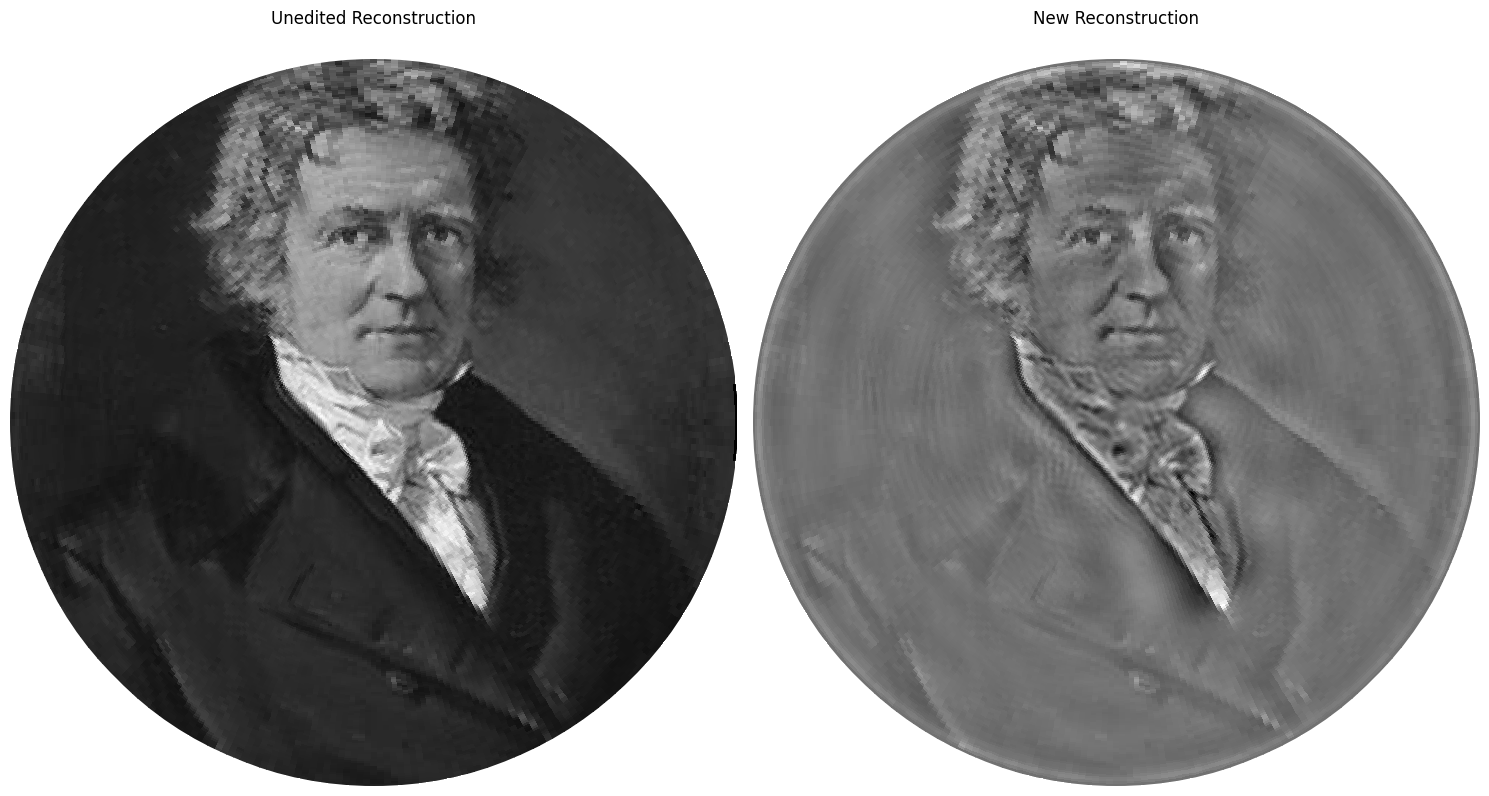

In [14]:
custom_image = FFT_DHT.spec_to_phys(coeffs_post).real

fig, ax = plt.subplots(1, 2, figsize=(15, 8))

# ax[0].imshow(custom_image.T, cmap='gray', aspect='auto')
# ax[0].set_title("Unwrapped Reconstruction")
# ax[0].set_xlabel('Theta (q)')

# Plot
ax[0].remove() # need to make polar projection
ax[0] = fig.add_subplot(1, 2, 1, projection='polar')
ax[0].pcolormesh(FFT_DHT.TH, FFT_DHT.R, polar_image, cmap='gray', shading='auto')
ax[0].set_theta_direction(-1)
ax[0].set_theta_zero_location("E")
ax[0].set_title("Unedited Reconstruction")
ax[0].set_axis_off()


ax[1].remove() # need to make polar projection
ax[1] = fig.add_subplot(1, 2, 2, projection='polar')


ax[1].pcolormesh(FFT_DHT.TH, FFT_DHT.R, custom_image, cmap='gray', shading='auto')

ax[1].set_theta_direction(-1)
ax[1].set_theta_zero_location("E")
ax[1].set_title("New Reconstruction")
ax[1].set_axis_off()
plt.tight_layout()
plt.show()

Sources
- Pinsky $\S$ 3.2
- Arfken Weber $\S$ 8.2
- [An improved method for computing a discrete Hankel transform](https://www.sciencedirect.com/science/article/pii/0010465587902049)

Additional reading

- https://mathworld.wolfram.com/Fourier-BesselSeries.html
- https://en.wikipedia.org/wiki/Bessel_function 
- https://users.math.msu.edu/users/gnagy/teaching/ode-2ed.pdf
- https://arxiv.org/pdf/2005.06076
- https://en.wikipedia.org/wiki/Non-uniform_discrete_Fourier_transform
- [Fourier Analysis in Polar and Sperical Coordinates](https://lmb.informatik.uni-freiburg.de/Publications/2008/WRB08/wa_report01_08.pdf)